# Entraînement d'un CNN custom sur le dataset COVID-19 Radiography

Ce notebook :
1. Utilise un dataset prétraité (via `prepro.py`) — masking + cropping + CLAHE + denoising,
2. construit un pipeline `tf.data` avec **normalisation à la volée** (les images sont stockées en PNG uint8, la normalisation ne peut pas être faite en amont),
3. entraîne un CNN custom (pas de transfer learning) avec pondération des classes (dataset déséquilibré),
4. évalue le modèle sur un jeu de test dédié.

Pensé pour tourner sur Colab GPU avec le dataset complet


In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model, layers

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
def normalize_image_tf(img: tf.Tensor, method='minmax'):
    """
    Normalise une image TensorFlow selon la méthode spécifiée.
    """
    #  tf.Tensor = l'équivalent TensorFlow d'un np.ndarray

    img = tf.cast(img, tf.float32) # On convertit l'image en float32 pour éviter les problèmes de type lors des opérations suivantes

    reduce_axes = list(range(1, img.shape.rank)) if img.shape.rank == 4 else None
    # img.shape.rank donne le nombre de dimensions du tenseur img. Si img est un tenseur 4D (par exemple, un lot d'images en format
    # (batch size, height, width, channels)). Imagine une pile de 32 feuilles (batch_size). Chaque feuille est une grille de 256×256 cases (height , width).
    # Chaque case contient 1 seul nombre ou 3 nombres (R, G, B) si c'était une image couleur (channels).
    # on veut réduire les axes 1, 2 et 3 (hauteur, largeur, canaux) pour calculer les statistiques
    # sur chaque image individuellement. Si img n'est pas 4D, on ne réduit pas d'axes.

    # reduce_axes vaut [1, 2, 3] si img est un tenseur 4D (batch d'images), sinon None (pas de réduction d'axes).

    if method == 'minmax': # On normalise les images en utilisant la méthode Min-Max, qui consiste à ramener les valeurs des pixels dans l'intervalle [0, 1]
                           # en soustrayant le minimum et en divisant par l'écart entre le maximum et le minimum.
                           # On fait cette normalisation pour chaque image individuellement (d'où l'utilisation de reduce_axes).
                           # Donc chaque image du batch sera normalisée indépendamment des autres.

        img_min = tf.reduce_min(img, axis=reduce_axes, keepdims=True) # Calcule le minimum pour chaque image (en gardant les dimensions pour le broadcasting i.e. pour que la soustraction fonctionne correctement)
        img_max = tf.reduce_max(img, axis=reduce_axes, keepdims=True) # Calcule le maximum pour chaque image (idem)

        # img_min et img_max ont la forme (N, 1, 1, 1) - PAS la même forme que img (N, H, W, C) : les axes
        # réduits passent à 1 (grâce à keepdims=True), au lieu de disparaître. C'est justement parce que
        # les formes diffèrent (mais sont compatibles) que le broadcasting fonctionne : lors de la
        # soustraction/division, chaque valeur "1" se répète virtuellement pour matcher H, W, C.

        # Cela permet de soustraire le minimum et de diviser par l'écart pour chaque image individuellement.

        return (img - img_min) / (img_max - img_min + 1e-8) # pour éviter la division par zéro, on ajoute un petit epsilon (1e-8) à l'écart.

    elif method == 'standard':  # On normalise les images en utilisant la méthode de standardisation, qui consiste à soustraire la moyenne et à diviser par l'écart-type.
                                # On fait cette normalisation pour chaque image individuellement (d'où l'utilisation de reduce_axes).
                                # Donc chaque image du batch sera standardisée indépendamment des autres.

        mean = tf.reduce_mean(img, axis=reduce_axes, keepdims=True)
        std = tf.math.reduce_std(img, axis=reduce_axes, keepdims=True)

        # mean et std ont la forme (N, 1, 1, 1) - PAS la même forme que img (N, H, W, C), même logique que
        # img_min/img_max ci-dessus : c'est la différence de forme (compatible via broadcasting) qui permet
        # à chaque valeur de se répéter virtuellement sur H, W, C lors de la soustraction/division.

        # Cela permet de soustraire la moyenne et de diviser par l'écart-type pour chaque image individuellement.

        return (img - mean) / (std + 1e-8)
    else:
        raise ValueError("method doit être 'minmax' ou 'standard'")

In [3]:
# Dataset déjà prétraité (masking + cropping + CLAHE), généré en amont et indépendamment de ce
# notebook via `python prepro.py --resolution 256 --masking --cropping --clahe`, puis zippé
# (ex: data/processed/256x256_L_masked_cropped_clahe.zip) et déposé sur Drive. A adapter si
# l'emplacement/nom sur ton Drive diffère.

import zipfile

from google.colab import drive

drive.mount('/content/drive') # le contenu du Drive est monté dans /content/drive, ce qui permet d'accéder aux fichiers stockés sur Google Drive depuis le notebook.


PROCESSED_ZIP_PATH = Path("/content/drive/MyDrive/DS_COVID/256x256_L_masked_cropped_clahe.zip") # A adapter si besoin
PROCESSED_EXTRACT_DIR = Path("/content/data/processed")

with zipfile.ZipFile(PROCESSED_ZIP_PATH) as zf:
    zf.extractall(PROCESSED_EXTRACT_DIR)

# On obtient /content/data/processed/256x256_L_masked_cropped_clahe/ qui contient les dossiers de classes (COVID, Normal, Lung_Opacity, Viral Pneumonia)

DATASET_DIR = PROCESSED_EXTRACT_DIR / PROCESSED_ZIP_PATH.stem

print(f"Dataset utilisé : {DATASET_DIR}")

CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

for class_name in CLASSES:
    class_dir = DATASET_DIR / class_name
    if not class_dir.exists():
        raise FileNotFoundError(
            f"Dossier de classe '{class_dir}' introuvable. Vérifiez le contenu de {PROCESSED_ZIP_PATH.name}."
        )
    print(f"Number of images in {class_name}: {len(list(class_dir.glob('*.png')))}")

Mounted at /content/drive
Dataset utilisé : /content/data/processed/256x256_L_masked_cropped_clahe
Number of images in COVID: 3616
Number of images in Normal: 10192
Number of images in Lung_Opacity: 6012
Number of images in Viral Pneumonia: 1345


In [4]:
# Config (à ajuster selon les besoins, mais IMG_SIZE doit correspondre à la résolution à laquelle le dataset a été généré)

IMG_SIZE = 256 # doit correspondre à la résolution à laquelle le dataset a été généré (ex: 256x256)
BATCH_SIZE = 32
SEED = 42
NORMALIZATION_METHOD = "minmax"  # 'minmax' ou 'standard', cf. src/common/utils.py
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
EPOCHS = 30

MODELS_DIR = Path("/content/drive/MyDrive/DS_COVID/models") # on crée un dossier pour stocker les modèles entraînés, à adapter si besoin
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Index des fichiers + split stratifié train/val/test

In [5]:
paths, labels = [], []
for class_idx, class_name in enumerate(CLASSES):
    files = sorted((DATASET_DIR / class_name).glob("*.png"))
    paths.extend(str(f) for f in files)
    labels.extend([class_idx] * len(files)) # ex labels = [0, 0, 0, ..., 1, 1, ..., 2, 2, ..., 3, 3, ...] où chaque classe est représentée par son index (0 pour COVID, 1 pour Normal, etc.) et chaque image du dataset est associée à son label correspondant.

paths, labels = np.array(paths), np.array(labels)
print(f"Total images : {len(paths)}")
for class_idx, class_name in enumerate(CLASSES):
    print(f"  {class_name}: {(labels == class_idx).sum()}")

# Split stratifié : train / (val+test), puis val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels,
    test_size=VAL_FRACTION + TEST_FRACTION,
    stratify=labels,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION), # on ajuste la taille du test par rapport à la taille de X_temp (qui est VAL_FRACTION + TEST_FRACTION)
    stratify=y_temp,
    random_state=SEED,
)

print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")


Total images : 21165
  COVID: 3616
  Normal: 10192
  Lung_Opacity: 6012
  Viral Pneumonia: 1345

Train: 14815  Val: 3175  Test: 3175


## 2. Pipeline `tf.data` : chargement du PNG déjà prétraité + normalisation

Le masking/cropping/CLAHE a déjà été appliqué par `prepro.py` et est baké dans les fichiers PNG de `DATASET_DIR`. Ici on ne fait que décoder l'image et la normaliser (float32), étape qui ne peut pas être persistée en PNG (uint8).

In [6]:
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1) # On décode l'image PNG en un tenseur TensorFlow avec 1 canal (grayscale)
    img = normalize_image_tf(img, method=NORMALIZATION_METHOD)
    return img, label


def make_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)) # On crée un dataset TensorFlow à partir des chemins d'images et des labels correspondants. Chaque élément du dataset est un tuple (chemin, label).
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED) # On mélange les données pour l'entraînement afin d'améliorer la généralisation du modèle. Le buffer_size est la taille du tampon de mélange, ici on utilise la taille totale du dataset pour un mélange complet. Le seed est utilisé pour rendre le mélange reproductible.
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE) # On applique la fonction load_and_preprocess à chaque élément du dataset (chemin, label) pour charger et prétraiter les images. num_parallel_calls=tf.data.AUTOTUNE permet à TensorFlow de déterminer automatiquement le nombre optimal de threads pour paralléliser cette opération.
    ds = ds.batch(BATCH_SIZE) # On regroupe les éléments du dataset en lots (batches) de taille BATCH_SIZE. Cela permet d'optimiser l'entraînement du modèle en traitant plusieurs images à la fois.
    ds = ds.prefetch(tf.data.AUTOTUNE) # On précharge les lots suivants pendant que le modèle est en train de traiter le lot actuel, ce qui permet d'améliorer les performances d'entraînement en réduisant le temps d'attente pour les données.
    return ds


train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)


Batch shape: (32, 256, 256, 1) <dtype: 'float32'>
Min/max après normalisation: 0.0 1.0


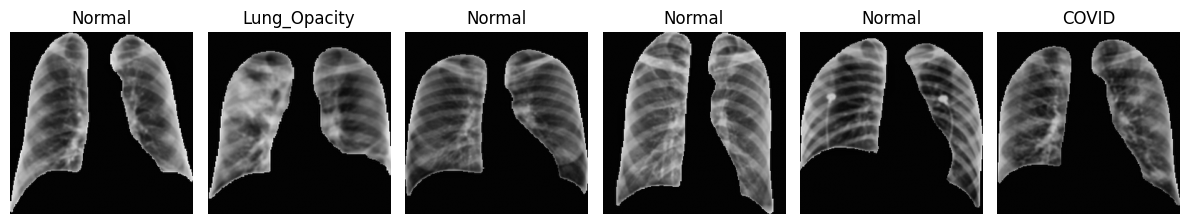

In [7]:
# Sanity check : un batch, la plage de valeurs après normalisation, quelques images
for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape, imgs.dtype)
    print("Min/max après normalisation:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))

    plt.figure(figsize=(12, 4))
    for i in range(min(6, imgs.shape[0])):
        plt.subplot(1, 6, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.title(CLASSES[int(lbls[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Class weights (dataset déséquilibré)

In [8]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'COVID': np.float64(1.463), 'Normal': np.float64(0.519), 'Lung_Opacity': np.float64(0.88), 'Viral Pneumonia': np.float64(3.932)}


## 4. CNN custom

In [9]:
def build_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Data augmentation : actif seulement en training (model.fit), inerte en evaluate/predict
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.1)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs, name="covid_cnn")


model = build_cnn((IMG_SIZE, IMG_SIZE, 1), len(CLASSES))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "covid_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,172 (1.61 MB)

 Trainable params: 422,212 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Entraînement

In [10]:
run_name = f"cnn_custom_{datetime.now().strftime('%Y%m%d-%H%M%S')}"

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / f"{run_name}_best.keras", monitor="val_loss", save_best_only=True
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 89s 170ms/step - accuracy: 0.5861 - loss: 0.8847 - val_accuracy: 0.4816 - val_loss: 3.4744 - learning_rate: 0.0010
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 77s 166ms/step - accuracy: 0.6661 - loss: 0.7029 - val_accuracy: 0.6907 - val_loss: 0.7854 - learning_rate: 0.0010
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.7070 - loss: 0.6329 - val_accuracy: 0.6271 - val_loss: 0.8378 - learning_rate: 0.0010
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 79s 171ms/step - accuracy: 0.7254 - loss: 0.5913 - val_accuracy: 0.5282 - val_loss: 1.7661 - learning_rate: 0.0010
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - accuracy: 0.7507 - loss: 0.5584 - val_accuracy: 0.7235 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.7669 - loss: 0.5320 - val_accuracy: 0.6425 - val_loss: 1.2892 - learning_rate: 0.0010
Epoch 7/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 81s 175ms/step - accuracy: 0.7

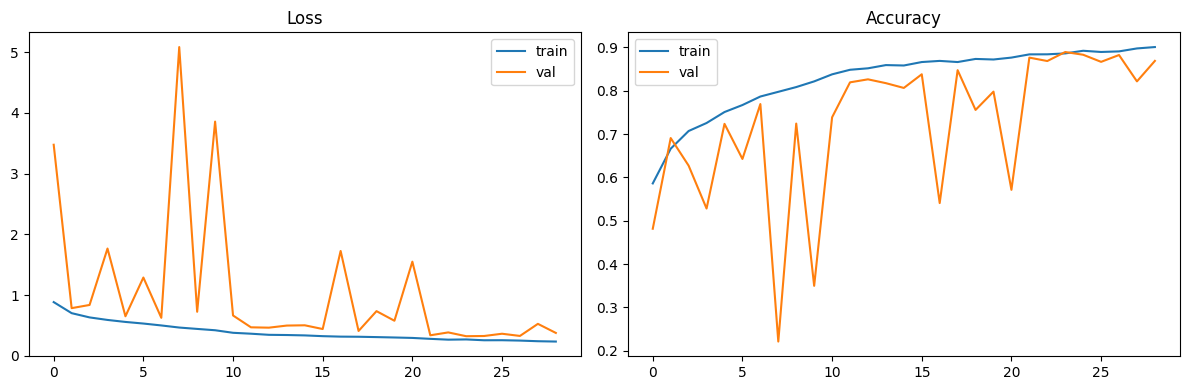

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Évaluation sur le jeu de test

Test loss: 0.3380  Test accuracy: 0.8769

Classification report:

                 precision    recall  f1-score   support

          COVID       0.76      0.87      0.81       542
         Normal       0.93      0.90      0.92      1529
   Lung_Opacity       0.85      0.83      0.84       902
Viral Pneumonia       0.95      0.94      0.94       202

       accuracy                           0.88      3175
      macro avg       0.87      0.88      0.88      3175
   weighted avg       0.88      0.88      0.88      3175



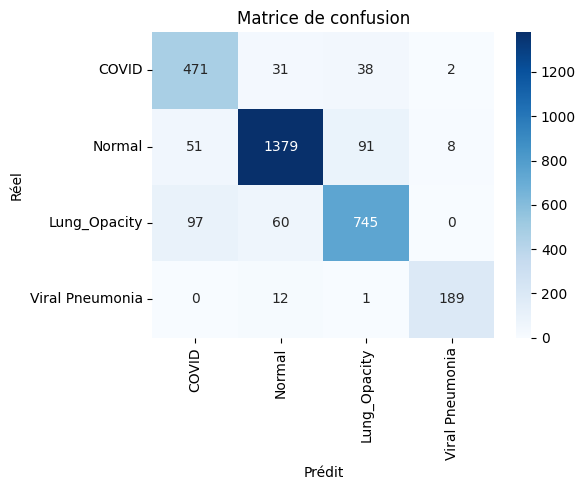

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

y_pred_proba = model.predict(test_ds, verbose=0)  # y_test déjà dispo (cf. split) ; make_dataset() ne shuffle jamais test_ds donc l'ordre reste aligné
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

## 7. Sauvegarde du modèle final

In [13]:
final_path = MODELS_DIR / f"{run_name}_final.keras"
model.save(final_path)
print(f"Modèle sauvegardé dans : {final_path}")

Modèle sauvegardé dans : /content/drive/MyDrive/DS_COVID/models/cnn_custom_20260819-124818_final.keras
